This notebook contains some examples of figures created by the code in this repository.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
import datetime
import scipy

## Daily price returns time series analysis

A time series of the historical closing price of gold is taken from Yahoo Finance. The log daily returns are calculated and plotted as a histogram and compared to a fitted Normal distribution.

In [3]:
from get_price_returns import download_financial_data, calculate_log_daily_returns, plot_daily_returns_hist

In [ ]:
ticker = 'GC=F'

start_date = datetime.datetime(2019, 1, 1)
end_date = datetime.datetime(2026, 1, 1)

closing_prices = download_financial_data(ticker, start_date, end_date)

In [ ]:
closing_prices.describe()

In [ ]:
log_daily_returns = calculate_log_daily_returns(closing_prices)
log_daily_returns.describe()

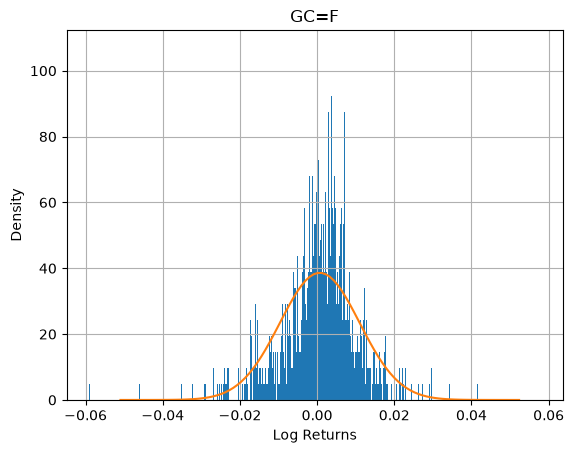

In [ ]:
plot_daily_returns_hist(ticker, log_daily_returns)

## Monte-Carlo mean-variance portfolio optimisation

Generate a sample of random portfolios for a given asset universe and plot the efficient frontier. The global minimum variance and tangency portfolios are labelled.

In [2]:
import markowitz_model as mm

In [9]:
n_trading_days = 252    # trading days in a year
n_portfolios = 2000    # number of random portfolios to generate

assets = ['AAPL', 'WMT', 'TSLA', 'GE', 'AMZN']  # asset universe
start_date = datetime.date(2019, 1, 1)
end_date = datetime.date.today()
risk_free_rate = 0.05

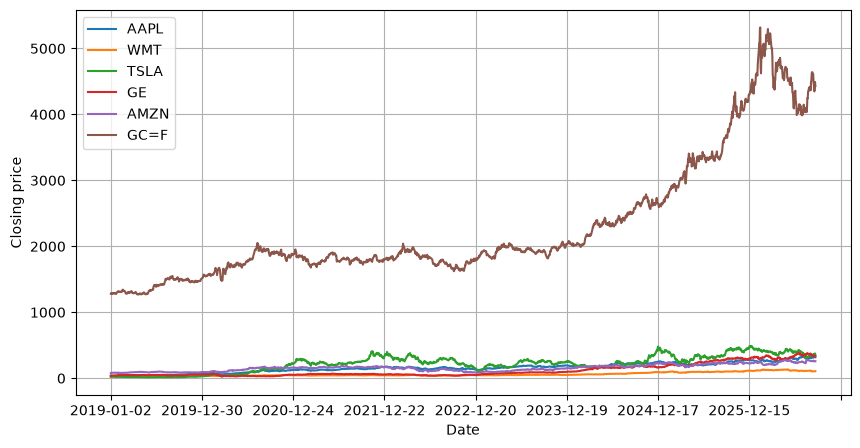

In [10]:
#dataset = mm.download_data(assets, start_date, end_date)
#dataset.to_csv("testing_dataset.csv")
dataset = pd.read_csv("testing_dataset.csv", index_col=0)
mm.show_data(dataset, 'Date', 'Closing price')

In [5]:
log_daily_returns = mm.calculate_returns(dataset)
mm.show_statistics(log_daily_returns, n_trading_days)

Mean annual returns
AAPL    0.29
WMT     0.17
TSLA    0.38
GE      0.29
AMZN    0.16
GC=F    0.16
dtype: float64
Covariance matrix
      AAPL   WMT  TSLA    GE  AMZN  GC=F
AAPL  0.09  0.02  0.09  0.04  0.06  0.00
WMT   0.02  0.05  0.02  0.01  0.02  0.00
TSLA  0.09  0.02  0.40  0.06  0.09  0.01
GE    0.04  0.01  0.06  0.15  0.04  0.00
AMZN  0.06  0.02  0.09  0.04  0.12  0.00
GC=F  0.00  0.00  0.01  0.00  0.00  0.03


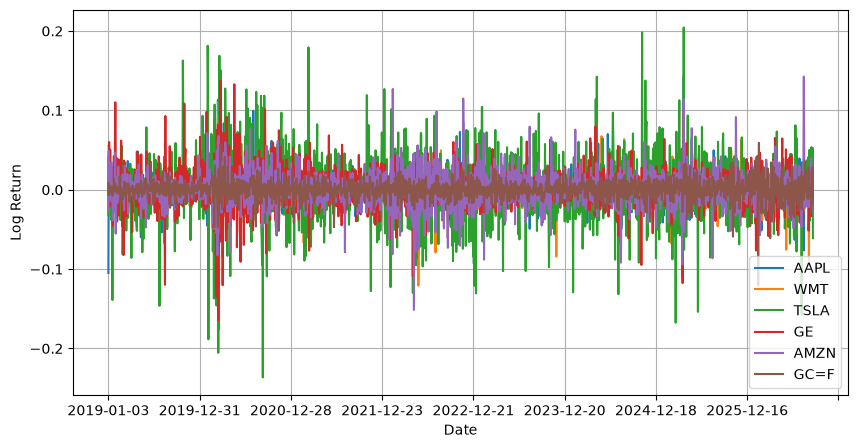

In [6]:
mm.show_data(log_daily_returns, 'Date', 'Log Return')

Expected return and volatility with an **equal-weighted** portfolio

In [7]:
weights = np.ones(len(assets)) / len(assets)
mu, sigma, S = mm.get_portfolio_statistics(weights, log_daily_returns, n_trading_days, risk_free_rate)
print("Expected return: ", np.round(mu, 2))
print("Expected volatility: ", np.round(sigma, 2))
print("Sharpe ratio: ", np.round(S, 2))

Expected return:  0.24
Expected volatility:  0.22
Sharpe ratio:  0.86


### Generate random portfolios and plot risk-return and Sharpe ratio:

Expected portfolio return
\begin{equation}
\mu = \boldsymbol{\omega}^{T}\boldsymbol{\mu}
\end{equation}

Expected portfolio volatility
\begin{equation}
\sigma = \sqrt{\boldsymbol{\sigma}^{T}\boldsymbol{\Sigma}\boldsymbol{\sigma}}
\end{equation}

Sharpe ratio
\begin{equation}
S = \frac{\mu - r}{\sigma}
\end{equation}

Maximum Sharpe Ratio:  1.03
Tangency Portfolio Sharpe Ratio:  1.2
Global Minimum Variance Portfolio Sharpe Ratio:  1.09


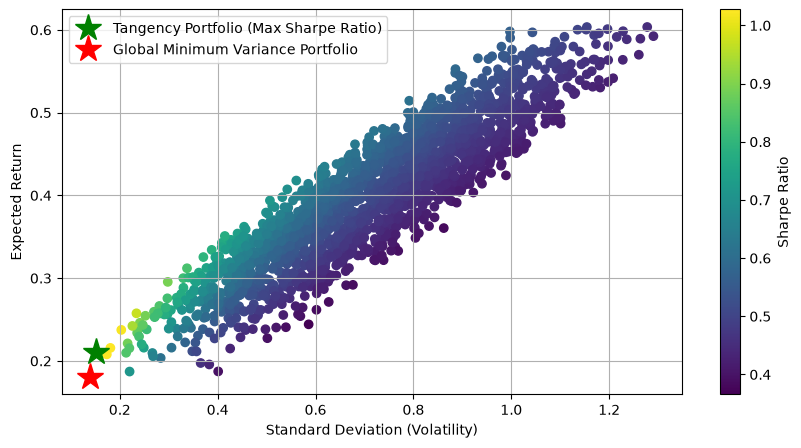

In [8]:
mm.plot_portfolios(assets, log_daily_returns, n_portfolios, n_trading_days, risk_free_rate=0.03)